# Manuscript figure: per-vertex tetrahedral constraints in 3D

The 2D two-triangle check anchors **2 triangles per pixel** (see
`01_signed_areas.ipynb`). The 3D analog anchors **6 tetrahedra per vertex**,
drawn from **3 distinct source cells** — the cells lying on the $-x$, $-y$
and $-z$ sides of the focal vertex $p$. Each source cell contributes 2 of
its 6 body-diagonal tets to $p$, and inside that cell $p$ sits at the
local corner $B$, $C$, or $E$ respectively.

This is the structural picture used to set up the per-vertex SLSQP
constraints: when the solver nudges $\phi(p)$, exactly these 6 tet
volumes change, no others.

Panels:

- **(a)** All 3 source cells around $p$ with their 6 owned tetrahedra,
  colored by source cell.
- **(b)** $-x$ source cell isolated, with tets $T_1, T_2$ filled. The
  focal vertex sits at this cell's $B$ corner.
- **(c)** $-y$ source cell, tets $T_3, T_4$, focal vertex at $C$.
- **(d)** $-z$ source cell, tets $T_5, T_6$, focal vertex at $E$.

Cube-corner labels $A, \ldots, H$ and tet indices $T_1, \ldots, T_6$
follow the same body-diagonal convention as `02_tet_decomposition.ipynb`.

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath('../..'))

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

## Geometry — per-vertex anchor table

Cube corners $A, \ldots, H$ are indexed by their $(z, y, x)$ offset bits
($A$ is the local origin, $H$ is the body-diagonal endpoint).
The six tetrahedra $T_1, \ldots, T_6$ are the body-diagonal decomposition
of the cube (one per monotone $A \to H$ path), matching the 6-tet table
in notebook `02_tet_decomposition.ipynb`.

The **per-vertex anchor rule** assigns each interior vertex $p = (z, y, x)$
exactly the 6 tets in the following table:

| tet | path | source cell $(c_z, c_y, c_x)$ | local corner of $p$ in that cell |
| --- | --- | --- | --- |
| $T_1$ | $x, y, z$ | $(z, y, x{-}1)$ — the $-x$ neighbour | $B = (0, 0, 1)$ |
| $T_2$ | $x, z, y$ | $(z, y, x{-}1)$ — the $-x$ neighbour | $B = (0, 0, 1)$ |
| $T_3$ | $y, x, z$ | $(z, y{-}1, x)$ — the $-y$ neighbour | $C = (0, 1, 0)$ |
| $T_4$ | $y, z, x$ | $(z, y{-}1, x)$ — the $-y$ neighbour | $C = (0, 1, 0)$ |
| $T_5$ | $z, x, y$ | $(z{-}1, y, x)$ — the $-z$ neighbour | $E = (1, 0, 0)$ |
| $T_6$ | $z, y, x$ | $(z{-}1, y, x)$ — the $-z$ neighbour | $E = (1, 0, 0)$ |

So $p$ is the corner where the three source cubes meet — each cube
extending in $\{+y, +z, -x\}$, $\{+x, +z, -y\}$, $\{+x, +y, -z\}$ from
$p$ respectively — and each cube contributes 2 tets through $p$. The
remaining 5 voxel cells around $p$ (the cells on the $+x$, $+y$, $+z$
sides and their mixed combinations) are owned by other vertices, not by
$p$ — they would double-count if included here.

In [2]:
# 8 cube corners as (z, y, x) offsets, labeled A..H.
CUBE_CORNERS = np.array([
    [0, 0, 0],  # A
    [0, 0, 1],  # B
    [0, 1, 0],  # C
    [0, 1, 1],  # D
    [1, 0, 0],  # E
    [1, 0, 1],  # F
    [1, 1, 0],  # G
    [1, 1, 1],  # H
], dtype=np.int8)

# 6 tetrahedra: each row is the monotone A -> ... -> H path. T_1..T_6
# in figure labels (0-indexed in code). Same convention as 02_tet_decomposition.
TET_INDICES = np.array([
    [0, 1, 3, 7],   # T_1 -- path x, y, z   -- anchor at B
    [0, 1, 5, 7],   # T_2 -- path x, z, y   -- anchor at B
    [0, 2, 3, 7],   # T_3 -- path y, x, z   -- anchor at C
    [0, 2, 6, 7],   # T_4 -- path y, z, x   -- anchor at C
    [0, 4, 5, 7],   # T_5 -- path z, x, y   -- anchor at E
    [0, 4, 6, 7],   # T_6 -- path z, y, x   -- anchor at E
], dtype=np.int8)

# 12 cube edges.
CUBE_EDGES = [
    (0, 1), (0, 2), (0, 4), (1, 3), (1, 5), (2, 3),
    (2, 6), (3, 7), (4, 5), (4, 6), (5, 7), (6, 7),
]

# Per-vertex anchor rule, encoded as (tet_index, source_cell_offset_zyx,
# focal_local_vi). When the focal vertex is at world (0, 0, 0), the source
# cell offsets below are the cell's (cz, cy, cx) -- so e.g. (0, 0, -1) is
# the cell whose v_min corner is at (0, 0, -1) and whose v_max is at
# (1, 1, 0); the focal vertex sits at its v_1 = B = (0, 0, 1) corner.
ANCHOR_TABLE = [
    (0, (0,  0, -1), 1),   # T_1 in -x cell, p = B
    (1, (0,  0, -1), 1),   # T_2 in -x cell, p = B
    (2, (0, -1,  0), 2),   # T_3 in -y cell, p = C
    (3, (0, -1,  0), 2),   # T_4 in -y cell, p = C
    (4, (-1, 0,  0), 4),   # T_5 in -z cell, p = E
    (5, (-1, 0,  0), 4),   # T_6 in -z cell, p = E
]

# Source-cell colours: one hue per cell (both of that cell's owned tets
# share the colour, since the figure's message is "which cell does each
# tet come from").
CELL_COLOR_X = '#1f77b4'   # -x cell tets (T_1, T_2) -- blue
CELL_COLOR_Y = '#2ca02c'   # -y cell tets (T_3, T_4) -- green
CELL_COLOR_Z = '#ff7f0e'   # -z cell tets (T_5, T_6) -- orange
TET_COLORS = [CELL_COLOR_X, CELL_COLOR_X,
              CELL_COLOR_Y, CELL_COLOR_Y,
              CELL_COLOR_Z, CELL_COLOR_Z]
CELL_COLOR_BY_OFFSET = {
    (0,  0, -1): CELL_COLOR_X,
    (0, -1,  0): CELL_COLOR_Y,
    (-1, 0,  0): CELL_COLOR_Z,
}

# Focal-vertex star marker -- same yellow-star convention as the 2D
# notebook 01_signed_areas to visually link the per-vertex framings.
FOCAL_COLOR = '#ffd54f'
FOCAL_EDGE  = '#5d4037'


def xyz(corner_zyx):
    '''(z, y, x) offset -> (x, y, z) for matplotlib 3D axes.'''
    return float(corner_zyx[2]), float(corner_zyx[1]), float(corner_zyx[0])


def vertex_label(i):
    return chr(ord('A') + int(i))


def tet_label(t):
    return f'T_{{{t + 1}}}'


# Sanity: confirm the anchor table picks the right local corner for each
# source cell -- i.e. corner v_A of the cell, when translated by the cell's
# offset, lands exactly on (0, 0, 0) = world position of the focal vertex.
for tet_idx, offset_zyx, focal_vi in ANCHOR_TABLE:
    cz, cy, cx = offset_zyx
    fz, fy, fx = CUBE_CORNERS[focal_vi]
    world_zyx = (cz + fz, cy + fy, cx + fx)
    assert world_zyx == (0, 0, 0), (
        f'T_{tet_idx + 1}: cell offset {offset_zyx} + local v_{focal_vi} '
        f'= {world_zyx}, expected (0, 0, 0)')
    # Also: the anchor's local index must appear in this tet's vertex list.
    assert focal_vi in TET_INDICES[tet_idx], (
        f'T_{tet_idx + 1} does not include corner v_{focal_vi}')
print('anchor table OK -- every tet contains the focal corner '
      'and every (cell offset + focal corner) maps to (0, 0, 0)')

anchor table OK -- every tet contains the focal corner and every (cell offset + focal corner) maps to (0, 0, 0)


## Helpers

In [3]:
def cube_world_corners(cell_offset_zyx):
    '''Return the 8 world-coord corners of a cell at (cz, cy, cx).'''
    return CUBE_CORNERS + np.array(cell_offset_zyx, dtype=np.int8)


def draw_cube_edges(ax, cell_offset_zyx=(0, 0, 0), color='#555555',
                    lw=0.85, alpha=0.55):
    corners = cube_world_corners(cell_offset_zyx)
    for i, j in CUBE_EDGES:
        x0, y0, z0 = xyz(corners[i])
        x1, y1, z1 = xyz(corners[j])
        ax.plot([x0, x1], [y0, y1], [z0, z1],
                color=color, lw=lw, alpha=alpha)


def draw_cube_corners(ax, cell_offset_zyx=(0, 0, 0), label_size=9,
                      highlight_vi=None, highlight_label=None,
                      label_color='black'):
    '''Label corners A..H of a cell. If highlight_vi is set, that corner
    is drawn larger, with a warm fill and (optionally) a custom label
    (e.g. "p = B" instead of just "B").'''
    corners = cube_world_corners(cell_offset_zyx)
    for i, c in enumerate(corners):
        x, y, z = xyz(c)
        is_h = (highlight_vi is not None and i == highlight_vi)
        ax.scatter(x, y, z,
                   color='black' if is_h else '#555555',
                   s=30 if is_h else 18, zorder=11)
        text = f'${vertex_label(i)}$'
        if is_h and highlight_label is not None:
            text = f'${highlight_label}$'
        ax.text(x + 0.05, y + 0.05, z + 0.07, text,
                color=label_color, fontsize=label_size, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.16',
                          facecolor='#fff7e0' if is_h else 'white',
                          edgecolor='#444444' if is_h else '#bbbbbb',
                          linewidth=0.7, alpha=0.92),
                ha='left', va='bottom', zorder=12)


def draw_tet(ax, t_idx, cell_offset_zyx=(0, 0, 0), color=None,
             alpha=0.22, edge_lw=2.2, vertex_size=42, draw_path=True):
    '''Filled tet + monotone-path highlight + 4 vertex dots.'''
    if color is None:
        color = TET_COLORS[t_idx]
    inds = TET_INDICES[t_idx]
    corners = cube_world_corners(cell_offset_zyx)
    pts = np.array([xyz(corners[i]) for i in inds])
    faces = [
        [pts[0], pts[1], pts[2]],
        [pts[0], pts[1], pts[3]],
        [pts[0], pts[2], pts[3]],
        [pts[1], pts[2], pts[3]],
    ]
    ax.add_collection3d(Poly3DCollection(
        faces, facecolor=color, alpha=alpha,
        edgecolor=color, linewidth=0.5))
    if draw_path:
        for k in range(3):
            x0, y0, z0 = pts[k]
            x1, y1, z1 = pts[k + 1]
            ax.plot([x0, x1], [y0, y1], [z0, z1],
                    color=color, lw=edge_lw, alpha=0.95, zorder=9,
                    solid_capstyle='round')
    for vi in inds:
        x, y, z = xyz(corners[vi])
        ax.scatter(x, y, z, color=color, s=vertex_size, zorder=12,
                   edgecolor='black', linewidth=0.6)


def draw_focal_star(ax, world_zyx=(0, 0, 0), size=320):
    '''Yellow star marker for the focal vertex (matches 2D figure).'''
    cz, cy, cx = world_zyx
    ax.scatter(cx, cy, cz, marker='*',
               color=FOCAL_COLOR, edgecolor=FOCAL_EDGE,
               linewidth=1.4, s=size, zorder=20)


def style_3d_axes(ax, title='', zoom=1.4,
                  xlim=None, ylim=None, zlim=None,
                  title_y=-0.10):
    if xlim is not None:
        ax.set_xlim(*xlim)
    if ylim is not None:
        ax.set_ylim(*ylim)
    if zlim is not None:
        ax.set_zlim(*zlim)
    ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])
    ax.set_xlabel(''); ax.set_ylabel(''); ax.set_zlabel('')
    transparent = (1.0, 1.0, 1.0, 0.0)
    for axis in (ax.xaxis, ax.yaxis, ax.zaxis):
        axis.pane.fill = False
        axis.pane.set_edgecolor('white')
        axis.line.set_color(transparent)
    ax.grid(False)
    try:
        ax.set_box_aspect((1, 1, 1), zoom=zoom)
    except TypeError:
        ax.set_box_aspect((1, 1, 1))
        ax.dist = 10.0 / zoom
    ax.view_init(elev=22, azim=-58)
    if title:
        ax.set_title(title, fontsize=12, y=title_y)


def draw_axis_arrows(ax, anchor=(-0.05, 0.15), arrow_len=0.085,
                     with_labels=True, color='#222222', lw=1.8,
                     label_size=11):
    '''2D compass widget in axes-fraction coords. Same implementation as
    in 02_tet_decomposition.ipynb so the figure family looks uniform.'''
    from mpl_toolkits.mplot3d import proj3d
    proj = ax.get_proj()
    px_o, py_o, _ = proj3d.proj_transform(0, 0, 0, proj)
    deltas = {}
    for label, end in (('x', (1.0, 0.0, 0.0)),
                       ('y', (0.0, 1.0, 0.0)),
                       ('z', (0.0, 0.0, 1.0))):
        px, py, _ = proj3d.proj_transform(end[0], end[1], end[2], proj)
        v = np.array([px - px_o, py - py_o])
        deltas[label] = v / np.linalg.norm(v)
    cx, cy = anchor
    label_offset = 0.028
    for label, d in deltas.items():
        tip_x = cx + d[0] * arrow_len
        tip_y = cy + d[1] * arrow_len
        ax.annotate('', xy=(tip_x, tip_y), xytext=(cx, cy),
                    xycoords='axes fraction',
                    arrowprops=dict(arrowstyle='-|>', color=color,
                                    lw=lw, shrinkA=0, shrinkB=0),
                    zorder=15, annotation_clip=False)
        if with_labels:
            ax.text2D(tip_x + d[0] * label_offset,
                      tip_y + d[1] * label_offset,
                      f'${label}$',
                      transform=ax.transAxes,
                      color=color, fontsize=label_size, fontweight='bold',
                      ha='center', va='center', zorder=16, clip_on=False)

## Figure: 6 tetrahedra anchored at vertex $p$

Four panels in a single row.

- **(a)** Combined view: the focal vertex $p$ (yellow star) sits at the
  corner where the three source cubes meet. All 6 owned tets are drawn
  faintly, colored by source cell — blue for the $-x$ cell, green for
  $-y$, orange for $-z$. Tet path edges are dropped here to keep the
  combined picture readable; the per-cell panels below restore them.
- **(b–d)** Each source cell isolated, in its own local frame, with that
  cell's 2 owned tets filled at higher opacity, their monotone $A\to H$
  paths traced, and the focal corner relabeled $p = B$ / $p = C$ / $p = E$.
  The yellow star always sits on the focal corner, mirroring the 2D
  notebook's per-pixel rendering.

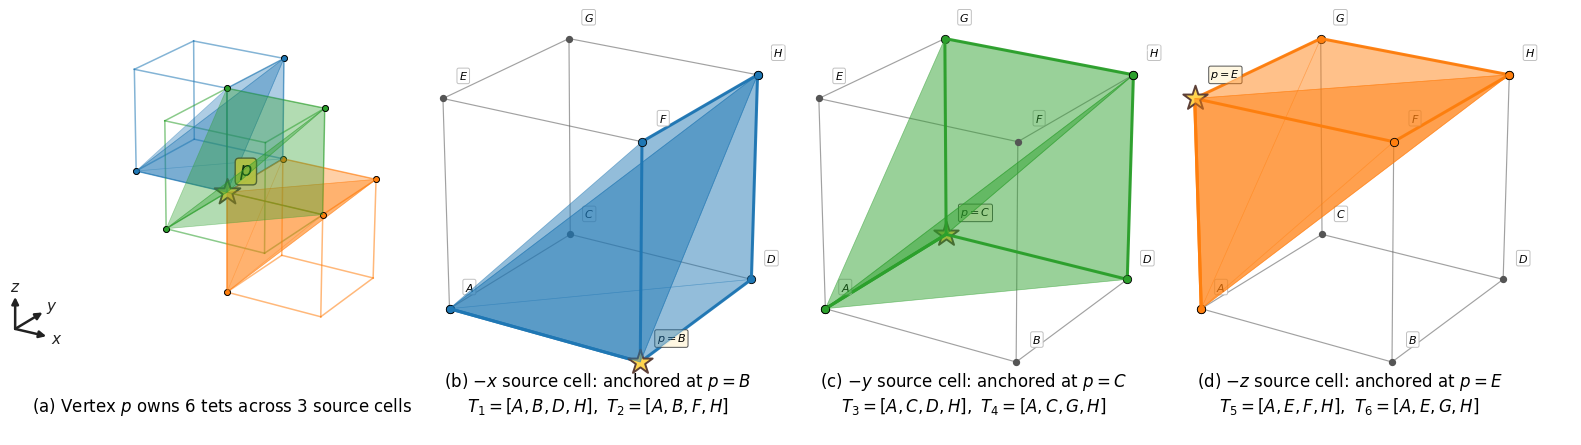

In [ ]:
fig = plt.figure(figsize=(15.5, 5.6))

# =========================================================================
# Panel (a): combined view -- all 3 source cells + all 6 owned tets
# =========================================================================
ax_a = fig.add_subplot(1, 4, 1, projection='3d')
# Source-cell wireframes, each in its cell's hue
for offset_zyx, color in CELL_COLOR_BY_OFFSET.items():
    draw_cube_edges(ax_a, offset_zyx, color=color, lw=1.1, alpha=0.55)
# 6 owned tets, low alpha, no path highlight (kept clean for the combined view)
for tet_idx, offset_zyx, _ in ANCHOR_TABLE:
    draw_tet(ax_a, tet_idx, offset_zyx, color=TET_COLORS[tet_idx],
             alpha=0.20, edge_lw=1.4, vertex_size=18, draw_path=False)
# Focal vertex star at world origin (= where all 3 cells meet)
draw_focal_star(ax_a, world_zyx=(0, 0, 0), size=380)
ax_a.text(0.08, 0.08, 0.10, '$p$',
          color='black', fontsize=14, fontweight='bold',
          bbox=dict(boxstyle='round,pad=0.20',
                    facecolor=FOCAL_COLOR, edgecolor=FOCAL_EDGE,
                    linewidth=1.0, alpha=0.95),
          ha='left', va='bottom', zorder=22)
# Panel (a) shows a 2x2x2 region (3 cells spanning [-1, +1] on every axis),
# so it needs a lower zoom + wider limits than the per-cell panels (which
# show only a 1x1x1 cube). With zoom=1.4 the cubes touch the top/right
# edges of the axes box.
style_3d_axes(ax_a,
              title=r'(a) Vertex $p$ owns 6 tets across 3 source cells',
              xlim=(-1.20, 1.20), ylim=(-1.20, 1.20), zlim=(-1.20, 1.20),
              zoom=1.18)
# Compass widget (after the projection is finalised by an explicit draw)
fig.canvas.draw()
draw_axis_arrows(ax_a)

# =========================================================================
# Panels (b), (c), (d): each source cell isolated with its 2 owned tets
# =========================================================================
# Each panel title also lists the two tets as ordered simplices
# [v_0, v_1, v_2, v_3] (the monotone A -> ... -> H path) so the reader can
# verify by eye that each pair shares the focal corner and the body
# diagonal A-H, differing only in which intermediate corner each tet takes.
def _ordered_simplex(t_idx):
    return '[' + ', '.join(vertex_label(int(i))
                            for i in TET_INDICES[t_idx]) + ']'


panel_specs = [
    {'offset': (0,  0, -1), 'tets': [0, 1], 'focal_vi': 1,
     'focal_letter': 'B',
     'title': (r'(b) $-x$ source cell: anchored at $p = B$'
               + '\n'
               + rf'$T_1 = {_ordered_simplex(0)}$,'
               + r'$\;\;$'
               + rf'$T_2 = {_ordered_simplex(1)}$')},
    {'offset': (0, -1,  0), 'tets': [2, 3], 'focal_vi': 2,
     'focal_letter': 'C',
     'title': (r'(c) $-y$ source cell: anchored at $p = C$'
               + '\n'
               + rf'$T_3 = {_ordered_simplex(2)}$,'
               + r'$\;\;$'
               + rf'$T_4 = {_ordered_simplex(3)}$')},
    {'offset': (-1, 0,  0), 'tets': [4, 5], 'focal_vi': 4,
     'focal_letter': 'E',
     'title': (r'(d) $-z$ source cell: anchored at $p = E$'
               + '\n'
               + rf'$T_5 = {_ordered_simplex(4)}$,'
               + r'$\;\;$'
               + rf'$T_6 = {_ordered_simplex(5)}$')},
]

for panel_i, spec in enumerate(panel_specs):
    ax = fig.add_subplot(1, 4, panel_i + 2, projection='3d')
    offset = spec['offset']
    color = CELL_COLOR_BY_OFFSET[offset]

    # Cell wireframe + labelled corners A..H, with the focal corner
    # relabeled "p = B" (or C / E).
    draw_cube_edges(ax, offset, color='#555555', lw=0.85, alpha=0.55)
    draw_cube_corners(ax, offset, label_size=8,
                      highlight_vi=spec['focal_vi'],
                      highlight_label=f"p = {spec['focal_letter']}")

    # The 2 owned tets, filled with the cell's hue. Path edges are
    # drawn here (panel (a) skips them); together they make the two
    # monotone A->H routes visible.
    for tet_idx in spec['tets']:
        draw_tet(ax, tet_idx, offset, color=color,
                 alpha=0.28, edge_lw=2.2, vertex_size=36, draw_path=True)

    # Yellow star at the focal cell corner (same point as the highlighted
    # A..H label, so they stack visually).
    cz, cy, cx = offset
    fz, fy, fx = CUBE_CORNERS[spec['focal_vi']]
    draw_focal_star(ax, world_zyx=(cz + fz, cy + fy, cx + fx), size=340)

    # Tight zoom on this one cell.
    corners = cube_world_corners(offset)
    xs = [c[2] for c in corners]
    ys = [c[1] for c in corners]
    zs = [c[0] for c in corners]
    pad = 0.20
    style_3d_axes(ax, title=spec['title'],
                  xlim=(min(xs) - pad, max(xs) + pad),
                  ylim=(min(ys) - pad, max(ys) + pad),
                  zlim=(min(zs) - pad, max(zs) + pad))

# Reserve a little left margin for panel (a)'s compass widget and remove
# horizontal spacing so the four panels read as a tight row. The bottom
# margin is generous to seat the two-line titles below each panel without
# clipping their second line.
fig.subplots_adjust(left=0.03, right=1.0, top=0.98, bottom=0.16,
                    wspace=0.0)

plt.show()

## Save figure

PNG + PDF go to `./output/per_vertex_tetrahedra/` (relative to this notebook).
The crop helper trims the empty 3D-decoration band matplotlib reserves
around each `Axes3D`.

In [5]:
import matplotlib.transforms as mtransforms


def _rendered_content_bbox(fig, pad_inches=0.12, near_white=250):
    '''Tight bbox in figure-inches of the visibly drawn pixels -- same
    helper used in 02_tet_decomposition for cropping the empty 3D-decor
    margins that bbox_inches=tight leaves behind.'''
    fig.canvas.draw()
    buf = np.asarray(fig.canvas.buffer_rgba())
    rgb = buf[..., :3]
    mask = (rgb < near_white).any(axis=-1)
    if not mask.any():
        return None
    rows = np.where(mask.any(axis=1))[0]
    cols = np.where(mask.any(axis=0))[0]
    h_px, w_px = buf.shape[:2]
    fw, fh = fig.get_size_inches()
    top_in    = fh * (1 - rows[0]  / h_px)
    bottom_in = fh * (1 - rows[-1] / h_px)
    left_in   = fw * (cols[0]      / w_px)
    right_in  = fw * (cols[-1]     / w_px)
    return mtransforms.Bbox.from_extents(
        max(0.0, left_in   - pad_inches),
        max(0.0, bottom_in - pad_inches),
        min(fw,  right_in  + pad_inches),
        min(fh,  top_in    + pad_inches),
    )


output_dir = 'output/per_vertex_tetrahedra'
os.makedirs(output_dir, exist_ok=True)

bbox = _rendered_content_bbox(fig)

fig.savefig(os.path.join(output_dir, 'per_vertex_tetrahedra.pdf'),
            bbox_inches=bbox)
fig.savefig(os.path.join(output_dir, 'per_vertex_tetrahedra.png'),
            dpi=300, bbox_inches=bbox)

print(f'Saved figure to {os.path.abspath(output_dir)}')

Saved figure to C:\Users\Andy\Documents\GitHub\UCI-iGravi\deformation-field-processing\notebooks\manuscript\output\per_vertex_tetrahedra
